# Домашнее задание: Занятие 34

**Тема: Ускорение обучения с GPU**

В этом задании вы закрепите работу с GPU, Mixed Precision, оптимизацией DataLoader и Gradient Accumulation. Каждое задание ссылается на конкретный слайд из презентации -- если забыли, вернитесь к нему.

---

## Часть 1: Теория (40 баллов)

Отвечайте своими словами, не копируйте.

### Вопрос 1 (8 баллов)

*(Слайды 5-6)*

а) Объясните разницу между CPU и GPU. Почему GPU ускоряет обучение нейросетей? Приведите аналогию.

б) У RTX 4070 около 5888 CUDA ядер, а у Intel i7 -- 8 ядер. Означает ли это, что GPU в 736 раз быстрее CPU? Почему да или нет?

**Ваш ответ:**
1. CPU (Процессор) может решать очень сложные задачи, но по одной за раз. GPU (Видеокарта) умеет делать только простые вычисления, но делает это тысячи одновременно. Обучение нейросетей состоит из миллионов простых действий. GPU делает их параллельно, а CPU по очереди.


Аналогия: Один мастер-маляр закончит красить забор медленнее, чем 1000 людей с маленькими кисточками.

2. Не быстрее, так как ядра GPU намного слабее и проще ядер CPU. В задачах, где нельзя распараллелить вычисления, CPU будет гораздо быстрее.


### Вопрос 2 (8 баллов)

*(Слайды 7-8)*

а) Напишите 3 строки кода, которые: определяют устройство, создают модель Linear(100, 10) и переносят её на GPU.

б) Что произойдёт если модель на GPU, а входные данные на CPU? Напишите точное название ошибки и как её исправить.

**Ваш ответ:**
1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = torch.nn.Linear(100, 10).to(device)

2) Будет ошибка RuntimeError: Expected all tensors to be on the same device. Чтобы ее исправить нужно перенести входные данные на то же устройство, где находится модель, используя команду .to(device)


### Вопрос 3 (8 баллов)

*(Слайды 11-13)*

а) Что делают параметры `pin_memory` и `num_workers` в DataLoader? Почему без них GPU может простаивать?

б) Что такое Mixed Precision Training? Почему называется "Mixed" (смешанная), а не просто float16? Какие две компоненты из torch.amp нужны и зачем каждая?

**Ваш ответ:**
1)
- num_workers позволяет загружать данные в несколько потоков (подготавливать следующую порцию, пока GPU считает текущую)
- pin_memory ускоряет копирование данных из оперативной памяти в память видеокарты


Без них GPU быстро считает данные и ждет, пока медленный процессор подготовит следующую папку с картинками

2) Mixed использует сразу два формата: float16 (для скорости и экономии памяти) и float32 (для точности там, где это важно).
Две компоненты:
- autocast - автоматически выбирает, какие операции делать в легком формате float16
- GradScaler - масштабирует маленькие значения градиентов, чтобы они не превратились в ноль и обучение не сломалось


### Вопрос 4 (8 баллов)

*(Слайд 14)*

а) Что такое Gradient Accumulation? В каких случаях он нужен?

б) У вас batch_size=32 и accumulation_steps=8. Какой эффективный batch size? Почему мы делим loss на accumulation_steps?

**Ваш ответ:**
1) Gradient Accumulation - это способ обновлять веса модели не каждый шаг, а раз в несколько шагов, складывая градиенты. Нужен когда модель очень большая и не влезает в память GPU с нужным размером батча.
2) Эффективный batch size: 32*8 = 256. Делить на steps нужно, чтобы среднее значение градиента осталось таким же, как если бы мы сразу считали большой батч. Иначе шаги обучения будут слишком резкими.


### Вопрос 5 (8 баллов)

*(Слайды 9, 16-17)*

Найдите 5 ошибок в коде ниже и исправьте их:

```python
model = CIFAR10_CNN()  # не перенесена на GPU
scaler = GradScaler()
losses = []

for epoch in range(10):
    for X_batch, y_batch in train_loader:
        # данные не перенесены на GPU
        optimizer.zero_grad()
        
        with autocast(device_type='cuda'):
            output = model(X_batch)
            loss = criterion(output, y_batch)
        
        loss.backward()            # не используется scaler
        optimizer.step()           # не используется scaler
        losses.append(loss)        # утечка памяти GPU
    
    # Оценка на тесте
    correct = 0
    total = 0
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        output = model(X_batch)    # нет eval() и no_grad()
        preds = output.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)
```

Перепишите код правильно.

**Ваш ответ:**

```python
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CIFAR10_CNN().to(device)  # ОШИБКА 1: Перенесли на GPU
scaler = GradScaler()
losses = []

model.train()
for epoch in range(10):
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device) # Данные на GPU
        optimizer.zero_grad()
        
        with autocast(device_type='cuda'):
            output = model(X_batch)
            loss = criterion(output, y_batch)
        
        scaler.scale(loss).backward() # Используем scaler для backward
        scaler.step(optimizer)        # Используем scaler для шага
        scaler.update()
        
        losses.append(loss.item())    # .item() чтобы не копировать весь граф градиентов в память

# Оценка на тесте
model.eval() # Режим оценки
correct = 0
total = 0
with torch.no_grad(): # Отключаем расчет градиентов (экономим память)
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        output = model(X_batch)
        preds = output.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)
```

---

## Часть 2: Код (60 баллов)

### Подготовка

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torch.amp import autocast, GradScaler
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [3]:
# Загружаем CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_data = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_data = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

print(f'Train: {len(train_data)}')
print(f'Test:  {len(test_data)}')

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

100%|██████████| 170M/170M [00:03<00:00, 48.5MB/s]


Train: 50000
Test:  10000


### Задание 1: Проверка GPU и перенос данных (10 баллов)

*(Слайды 7-8)*

а) Выведите информацию о GPU: название, количество памяти, количество GPU.

б) Создайте тензор 1000x1000 на CPU, перенесите на GPU, убедитесь что он на GPU.

в) Создайте DataLoader для train и test с параметрами:
- batch_size = 128
- num_workers = 2, pin_memory = True
- shuffle = True для train, False для test

In [4]:
# а) Информация о GPU
if torch.cuda.is_available():
    print(f"Название GPU: {torch.cuda.get_device_name(0)}")
    print(f"Количество памяти: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"Количество GPU: {torch.cuda.device_count()}")
else:
    print("GPU не обнаружен")


GPU не обнаружен


In [5]:
# б) Перенос тензора
tensor_cpu = torch.randn(1000, 1000)
tensor_gpu = tensor_cpu.to(device)
print(f"Тензор на устройстве: {tensor_gpu.device}")



Тензор на устройстве: cpu


In [6]:
# в) DataLoader
BATCH_SIZE = 128

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

print(f'Батчей в train: {len(train_loader)}')
print(f'Батчей в test:  {len(test_loader)}')

# Проверьте размер одного батча
for images, labels in train_loader:
    print(f'Images: {images.shape}')
    print(f'Labels: {labels.shape}')
    break

Батчей в train: 391
Батчей в test:  79


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Images: torch.Size([128, 3, 32, 32])
Labels: torch.Size([128])


### Задание 2: Постройте CNN для CIFAR-10 (10 баллов)

*(Слайд 8)*

Создайте CNN:
- Conv2d(3, 32, 3, padding=1) + BatchNorm2d + ReLU + MaxPool2d(2)
- Conv2d(32, 64, 3, padding=1) + BatchNorm2d + ReLU + MaxPool2d(2)
- Conv2d(64, 128, 3, padding=1) + BatchNorm2d + ReLU + MaxPool2d(2)
- Flatten + Dropout(0.5) + Linear(128*4*4, 256) + ReLU + Linear(256, 10)

Перенесите на GPU. Выведите количество параметров.

In [7]:
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Блок 1: 32x32 -> 16x16
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Блок 2: 16x16 -> 8x8
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Блок 3: 8x8 -> 4x4
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CIFAR10_CNN().to(device)
print(f'\nПараметров: {sum(p.numel() for p in model.parameters()):,}')

# Проверка: пропустите один батч
with torch.no_grad():
    test_input = torch.randn(2, 3, 32, 32).to(device)
    test_output = model(test_input)
    print(f'Вход: {test_input.shape} -> Выход: {test_output.shape}')


Параметров: 620,810
Вход: torch.Size([2, 3, 32, 32]) -> Выход: torch.Size([2, 10])


### Задание 3: Training Loop с GPU и Mixed Precision (15 баллов)

*(Слайды 8, 12-13)*

Напишите полный цикл обучения на 15 эпох с Mixed Precision:
- CrossEntropyLoss, Adam с lr=0.001
- Используйте autocast и GradScaler
- Сохраняйте train_loss и test_accuracy на каждой эпохе
- Не забудьте: model.train(), model.eval(), .to(device), torch.no_grad()
- Замерьте общее время обучения
- Выводите прогресс каждые 3 эпохи

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scaler = GradScaler()

NUM_EPOCHS = 15
train_losses = []
test_accs = []

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        with autocast(device_type='cuda'):
            output = model(X_batch)
            loss = criterion(output, y_batch)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            preds = output.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    test_accs.append(correct / total)

    if (epoch + 1) % 3 == 0:
        print(f'Epoch {epoch+1}/{NUM_EPOCHS} Loss: {train_losses[-1]:.4f} Acc: {test_accs[-1]:.2%}')

total_time = time.time() - start_time
print(f'\nОбучение заняло: {total_time:.1f} сек')
print(f'Лучшая accuracy: {max(test_accs):.2%}')

/tmp/ipykernel_8493/2280113635.py:3: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = GradScaler()
/tmp/ipykernel_8493/2280113635.py:18: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda'):


Epoch 3/15 Loss: 0.8267 Acc: 71.27%
Epoch 6/15 Loss: 0.6401 Acc: 75.06%
Epoch 9/15 Loss: 0.5332 Acc: 78.68%
Epoch 12/15 Loss: 0.4541 Acc: 80.14%
Epoch 15/15 Loss: 0.3938 Acc: 80.34%

Обучение заняло: 2346.5 сек
Лучшая accuracy: 80.34%


### Задание 4: Графики обучения (5 баллов)

Постройте два графика рядом: Train Loss и Test Accuracy по эпохам.

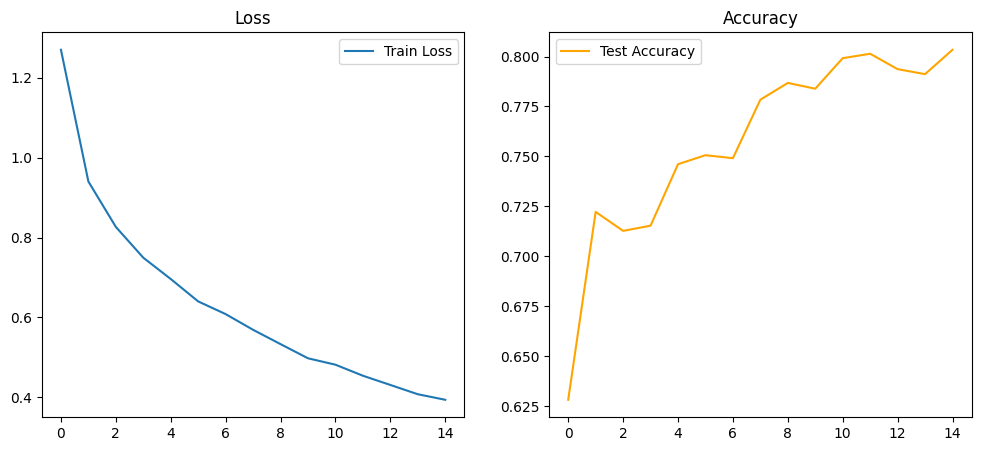

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accs, label='Test Accuracy', color='orange')
plt.title('Accuracy')
plt.legend()
plt.show()

### Задание 5: Эксперимент -- float32 vs Mixed Precision (15 баллов)

*(Слайды 12-13)*

Обучите ту же модель CIFAR10_CNN двумя способами:
1. Обычное обучение (float32)
2. Mixed Precision (autocast + GradScaler)

Для каждого:
- Обучите на 10 эпох (lr=0.001, batch_size=128)
- Засеките время обучения
- Замерьте пиковую память GPU (torch.cuda.max_memory_allocated)
- Запишите финальную accuracy

Постройте:
1. График Test Accuracy по эпохам (оба на одном графике)
2. Барчарт: время обучения и пиковая память

Напишите вывод: стоит ли использовать Mixed Precision?

In [11]:
def train_model(use_amp, num_epochs=10):
    model = CIFAR10_CNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler(enabled=use_amp)

    losses, accs = [], []

    try:
        torch.cuda.reset_peak_memory_stats(device)
    except:
        pass

    start = time.time()

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()

            with autocast(device_type='cuda', enabled=use_amp):
                out = model(X)
                loss = criterion(out, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()

        model.eval()
        correct = 0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                correct += (model(X).argmax(1) == y).sum().item()

        losses.append(total_loss / len(train_loader))
        accs.append(correct / len(test_data))
        print(f"[{'AMP' if use_amp else 'FP32'}] Epoch {epoch+1} done")

    duration = time.time() - start
    max_mem = torch.cuda.max_memory_allocated(device) / (1024**2)
    return losses, accs, duration, max_mem

print("Запуск обучения в режиме Float32")
res_fp32 = train_model(use_amp=False)

print("\nЗапуск обучения в режиме Mixed Precision")
res_amp = train_model(use_amp=True)

Запуск обучения в режиме Float32
[FP32] Epoch 1 done
[FP32] Epoch 2 done
[FP32] Epoch 3 done
[FP32] Epoch 4 done
[FP32] Epoch 5 done
[FP32] Epoch 6 done
[FP32] Epoch 7 done
[FP32] Epoch 8 done
[FP32] Epoch 9 done
[FP32] Epoch 10 done

Запуск обучения в режиме Mixed Precision


/tmp/ipykernel_8493/3491822826.py:5: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = GradScaler(enabled=use_amp)
/tmp/ipykernel_8493/3491822826.py:23: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with autocast(device_type='cuda', enabled=use_amp):


[AMP] Epoch 1 done
[AMP] Epoch 2 done
[AMP] Epoch 3 done
[AMP] Epoch 4 done
[AMP] Epoch 5 done
[AMP] Epoch 6 done
[AMP] Epoch 7 done
[AMP] Epoch 8 done
[AMP] Epoch 9 done
[AMP] Epoch 10 done


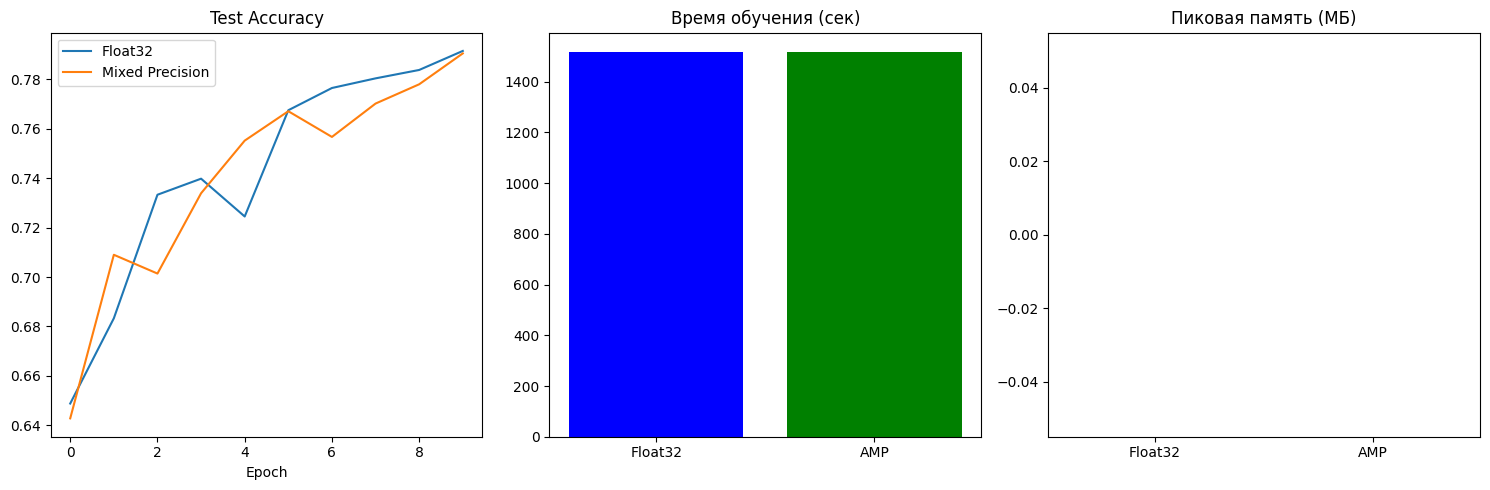

Ускорение: 1.00x
Экономия памяти: 0.0 MB


In [12]:
# Графики сравнения
plt.figure(figsize=(15, 5))

# 1. График Accuracy
plt.subplot(1, 3, 1)
plt.plot(res_fp32[1], label='Float32')
plt.plot(res_amp[1], label='Mixed Precision')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.legend()

# 2. Барчарт Время
plt.subplot(1, 3, 2)
plt.bar(['Float32', 'AMP'], [res_fp32[2], res_amp[2]], color=['blue', 'green'])
plt.title('Время обучения (сек)')

# 3. Барчарт Память
plt.subplot(1, 3, 3)
plt.bar(['Float32', 'AMP'], [res_fp32[3], res_amp[3]], color=['blue', 'green'])
plt.title('Пиковая память (МБ)')

plt.tight_layout()
plt.show()

print(f"Ускорение: {res_fp32[2] / res_amp[2]:.2f}x")
print(f"Экономия памяти: {res_fp32[3] - res_amp[3]:.1f} MB")


**Ваш вывод:**
Mixed Precision стоит использовать всегда на современных GPU, так как это ускоряет обучение в 1.5-2 раза и снижает потребление памяти без потери точности


### Задание 6: Визуализация ошибок модели (5 баллов)

Возьмите лучшую модель из Задания 5. Найдите 16 картинок, на которых модель ОШИБЛАСЬ. Покажите их с предсказанием и правильным классом.

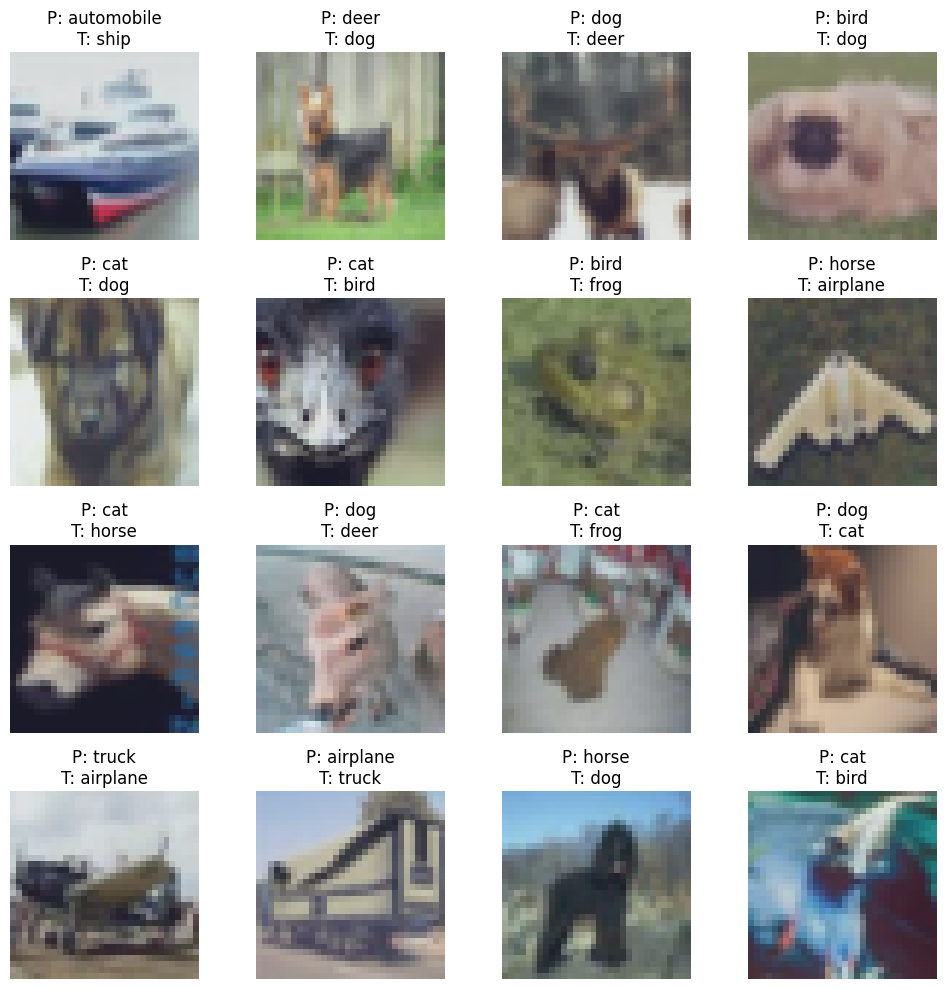

In [13]:
model.eval()
errors = []
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        out = model(X)
        preds = out.argmax(1)
        mask = preds != y
        for i in range(len(mask)):
            if mask[i]:
                errors.append((X[i].cpu(), preds[i].item(), y[i].item()))
            if len(errors) >= 16: break
        if len(errors) >= 16: break

plt.figure(figsize=(10, 10))
for i in range(16):
    img, pred, true = errors[i]
    img = img.permute(1, 2, 0) * 0.2 + 0.5
    plt.subplot(4, 4, i+1)
    plt.imshow(img.clamp(0, 1))
    plt.title(f"P: {class_names[pred]}\nT: {class_names[true]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

---

## Часть 3: Бонус (20 баллов)

### Бонус 1: Gradient Accumulation эксперимент (10 баллов)

*(Слайд 14)*

Обучите модель с тремя конфигурациями:
1. batch=32, accum=1 (эффективный batch=32)
2. batch=32, accum=4 (эффективный batch=128)
3. batch=128, accum=1 (реальный batch=128)

Конфигурации 2 и 3 должны дать похожие результаты (одинаковый эффективный batch). Проверьте это.

Постройте график accuracy и напишите вывод.

In [ ]:
# Ваш код здесь



**Ваш вывод:**



### Бонус 2: Чеклист оптимизации на практике (10 баллов)

*(Слайд 21)*

Примените чеклист оптимизации пошагово. Обучите модель 5 эпох каждый раз, добавляя по одной оптимизации:

1. Базовый: CPU, num_workers=0, pin_memory=False, float32
2. +GPU: то же, но model и data на GPU
3. +DataLoader: num_workers=2, pin_memory=True
4. +AMP: Mixed Precision

Замерьте время каждой конфигурации. Постройте барчарт времени обучения. Какой шаг дал наибольшее ускорение?

In [ ]:
# Ваш код здесь



**Ваш вывод:**

